In [1]:
import os
import scanpy as sc
import scipy.io
import pandas as pd
import numpy as np

# === 1. Set adata.X to raw_counts ===
adata = sc.read_h5ad('/fs/scratch/PAS2598/senes_raw/syn2580853/big_aging_cases_syn2580853_balanced_senepy.h5ad')

#adata.X = adata.layers["counts"]

adata = adata[adata.obs['cluster'].isin(['Astrocyte', 'Microglia', 'Oligodendrocyte Precursor Cell'])].copy()

In [5]:
# Extract and convert the counts layer
counts = adata.layers["counts"]

# Convert sparse to dense if necessary
if hasattr(counts, "toarray"):
    counts = counts.toarray()
elif hasattr(counts, "todense"):
    counts = np.array(counts.todense())
else:
    counts = np.array(counts)

# Get min and max
min_val = counts.min()
max_val = counts.max()

# Check if all values are integers
all_integers = np.all(np.equal(np.mod(counts, 1), 0))

print(f"Shape: {counts.shape}")
print(f"Min value: {min_val}")
print(f"Max value: {max_val}")
print(f"All values are integers: {all_integers}")

Shape: (158015, 34889)
Min value: 0.0
Max value: 4160.0
All values are integers: True


In [6]:
# Set adata.X to raw counts
adata.X = adata.layers["counts"].copy()

print("Max value:", adata.X.max())
print("Sample values:", adata.X[0:5, 0:5].toarray())

Max value: 4160.0
Sample values: [[0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [7]:
import os
import scanpy as sc
import scipy.io
import pandas as pd

# === CONFIG ===
output_dir = "psych_mixed_brain"
os.makedirs(output_dir, exist_ok=True)

# === 2. Export matrix.mtx.gz ===
scipy.io.mmwrite(
    os.path.join(output_dir, "matrix.mtx"),
    adata.X
)

# Optional: compress
import gzip
import shutil

with open(os.path.join(output_dir, "matrix.mtx"), 'rb') as f_in:
    with gzip.open(os.path.join(output_dir, "matrix.mtx.gz"), 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
os.remove(os.path.join(output_dir, "matrix.mtx"))  # remove uncompressed

# === 3. Export barcodes.tsv.gz ===
adata.obs_names.to_series().to_csv(
    os.path.join(output_dir, "barcodes.tsv.gz"),
    index=False, header=False, sep="\t", compression="gzip"
)

# === 4. Export features.tsv.gz ===
# If var_names are gene symbols, write with dummy gene IDs
genes = adata.var_names.to_series()
features = pd.DataFrame({
    "gene_id": genes,       # Can be changed to Ensembl IDs if available
    "gene_name": genes,
    "feature_type": "Gene Expression"
})
features.to_csv(
    os.path.join(output_dir, "features.tsv.gz"),
    index=False, header=False, sep="\t", compression="gzip"
)

print(f"✅ Export complete. Files saved in: {output_dir}")

✅ Export complete. Files saved in: psych_mixed_brain


In [8]:
# === 5. Export metadata ===
adata.obs.to_csv(os.path.join(output_dir, "obs_metadata.csv"))
adata.var.to_csv(os.path.join(output_dir, "var_metadata.csv"))

print(f"✅ Export complete. Files saved in: {output_dir}")

✅ Export complete. Files saved in: psych_mixed_brain


In [1]:
library(SeuratDisk)
library(Seurat)
library(SingleCellExperiment)
library(tidyverse)
library(DESeq2)

Registered S3 method overwritten by 'SeuratDisk':
  method            from  
  as.sparse.H5Group Seurat

Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Loading required package: SeuratObject

Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.3.3”

Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘SingleCellExperiment’ was built under R version 4.3.2”
Loading required package: SummarizedExperiment

Warning message:
“package ‘SummarizedExperiment’ was built under R version 4.3.2”
Loading required package: MatrixGenerics

Warning message:
“package ‘MatrixGenerics’ was built under R version 4.3.3”
Loading required package: matrixStats

Warning message:
“package ‘matrixStats’ was built under R version 4.3.3”

Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvg

In [2]:
library(Seurat)
library(Matrix)
library(data.table)

# === 1. Define file paths ===
dir_path <- "/users/PAS2598/ggaitos/2025/scripts/single-cell/deepsas/psychad_samples/psych_mixed_brain"

matrix_file   <- file.path(dir_path, "matrix.mtx.gz")
features_file <- file.path(dir_path, "features.tsv.gz")
barcodes_file <- file.path(dir_path, "barcodes.tsv.gz")
metadata_file <- file.path(dir_path, "obs_metadata.csv")

# === 2. Load matrix ===
matrix <- readMM(matrix_file)

# === 3. Load features (genes) and barcodes (cells) ===
features <- fread(features_file, header = FALSE)
barcodes <- fread(barcodes_file, header = FALSE)

# === 4. Fix orientation if needed ===
if (nrow(matrix) > ncol(matrix)) {
  message("Transposing matrix to genes x cells...")
  matrix <- t(matrix)
}

# === 5. Assign names ===
rownames(matrix) <- features$V2  # gene_name
colnames(matrix) <- barcodes$V1  # cell barcode

# === 6. Create Seurat object ===
seurat_obj <- CreateSeuratObject(counts = matrix)

# === 7. Add metadata ===
if (file.exists(metadata_file)) {
  metadata <- fread(metadata_file)
  metadata <- as.data.frame(metadata)
  rownames(metadata) <- metadata[[1]]
  metadata[[1]] <- NULL

  # Match metadata to cells
  shared_cells <- intersect(colnames(seurat_obj), rownames(metadata))
  metadata <- metadata[shared_cells, , drop = FALSE]
  seurat_obj <- subset(seurat_obj, cells = shared_cells)
  seurat_obj <- AddMetaData(seurat_obj, metadata)
}

# === 8. Done ===
cat("✅ Seurat object loaded:\n")
cat("  Cells:", ncol(seurat_obj), "\n")
cat("  Genes:", nrow(seurat_obj), "\n")

Warning message:
“package ‘Matrix’ was built under R version 4.3.3”

Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


The following object is masked from ‘package:S4Vectors’:

    expand



Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose


The following object is masked from ‘package:SummarizedExperiment’:

    shift


The following object is masked from ‘package:GenomicRanges’:

    shift


The following object is masked from ‘package:IRanges’:

    shift


The following objects are masked from ‘package:S4Vectors’:

    first, second


Transposing matrix to genes x cells...

Warning message:
“Feature names cannot have underscores ('_'), replaci

✅ Seurat object loaded:
  Cells: 158015 
  Genes: 34889 


In [3]:
seurat_obj

An object of class Seurat 
34889 features across 158015 samples within 1 assay 
Active assay: RNA (34889 features, 0 variable features)
 1 layer present: counts

In [4]:
DefaultAssay(seurat_obj) <- 'RNA'

In [5]:
seurat_obj

An object of class Seurat 
34889 features across 158015 samples within 1 assay 
Active assay: RNA (34889 features, 0 variable features)
 1 layer present: counts

In [6]:
print("Complete Single-Cell Integration + DESeq2 Workflow")

print("Available metadata columns:")
print(colnames(seurat_obj@meta.data))

# ============================================================================
# STEP 1: QUALITY CONTROL AND FILTERING
# ============================================================================

print("Step 1: Quality Control and Filtering")

# Calculate QC metrics
seurat_obj@meta.data$percent.mt <- PercentageFeatureSet(seurat_obj, pattern = "^MT-")
seurat_obj@meta.data$percent.ribo <- PercentageFeatureSet(seurat_obj, pattern = "^RP[SL]")

print("QC metrics before filtering:")
print(paste("Total cells:", ncol(seurat_obj)))
print(paste("Total genes:", nrow(seurat_obj)))
print("nFeature_RNA summary:")
print(summary(seurat_obj$nFeature_RNA))
print("nCount_RNA summary:")
print(summary(seurat_obj$nCount_RNA))
print("Percent MT summary:")
print(summary(seurat_obj$percent.mt))

# Visualize QC metrics
p1 <- FeatureScatter(seurat_obj, feature1 = "nCount_RNA", feature2 = "percent.mt")
p2 <- FeatureScatter(seurat_obj, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
print("QC scatter plots created")

# Quality control filtering
data <- subset(seurat_obj, subset = 
                     nFeature_RNA > 200 & 
                     nFeature_RNA < 6000 & 
                     nCount_RNA > 500 & 
                     percent.mt < 20)

print("After QC filtering:")
print(paste("Remaining cells:", ncol(data)))

# Check sample distribution
print("Sample distribution:")
print(table(data$Sample))
print("Condition distribution:")
print(table(data$hippocampus_SnC))
print("Cell type distribution:")
print(table(data$cluster))

[1] "Complete Single-Cell Integration + DESeq2 Workflow"
[1] "Available metadata columns:"
 [1] "orig.ident"                       "nCount_RNA"                      
 [3] "nFeature_RNA"                     "barcodekey_x"                    
 [5] "n_genes"                          "n_counts"                        
 [7] "class"                            "subclass"                        
 [9] "subtype"                          "AD_status"                       
[11] "DLBD_status"                      "FTD_status"                      
[13] "Tauopathy_status"                 "Vascular_status"                 
[15] "ASHCVD_status"                    "Schizophrenia"                   
[17] "Bipolar_Disorder"                 "Parkinson_disease"               
[19] "Tardive_dyskinesia"               "SubID_export_synapse"            
[21] "Source"                           "Aging"                           
[23] "Sample"                           "barcodekey_y"                    
[25] "Sex

Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



[1] "QC scatter plots created"
[1] "After QC filtering:"
[1] "Remaining cells: 155867"
[1] "Sample distribution:"

AMPAD_HBCC_0000000008 AMPAD_HBCC_0000000010 AMPAD_HBCC_0000000059 
                  889                  1273                  1634 
AMPAD_HBCC_0000000062 AMPAD_HBCC_0000000076 AMPAD_HBCC_0000000079 
                 1759                   744                  1422 
AMPAD_HBCC_0000000089 AMPAD_HBCC_0000000097 AMPAD_HBCC_0000000100 
                  153                  1920                   707 
AMPAD_HBCC_0000000103 AMPAD_HBCC_0000000128 AMPAD_HBCC_0000000129 
                 1288                  1749                   666 
AMPAD_HBCC_0000000174 AMPAD_HBCC_0000000207 AMPAD_HBCC_0000000210 
                 1063                  2690                   333 
AMPAD_HBCC_0000000226 AMPAD_HBCC_0000000231 AMPAD_HBCC_0000000348 
                 2132                   895                  1054 
AMPAD_HBCC_0000000354 AMPAD_HBCC_0000000421 AMPAD_MSSM_0000000207 
              

In [7]:
# ============================================================================
# STEP 2: NORMALIZATION AND VARIABLE FEATURE SELECTION
# ============================================================================

print("Step 2: Normalization and Variable Feature Selection")

# Normalize the data
data <- NormalizeData(data, 
                           normalization.method = "LogNormalize", 
                           scale.factor = 10000)

# Find highly variable features
data <- FindVariableFeatures(data, 
                                  selection.method = "vst", 
                                  nfeatures = 2000)

# Identify the 10 most highly variable genes
top10 <- head(VariableFeatures(data), 10)
print("Top 10 variable genes:")
print(top10)

# Plot variable features
plot1 <- VariableFeaturePlot(data)
plot2 <- LabelPoints(plot = plot1, points = top10, repel = TRUE)
print("Variable feature plot created")

[1] "Step 2: Normalization and Variable Feature Selection"


Normalizing layer: counts

Finding variable features for layer counts



[1] "Top 10 variable genes:"
 [1] "BCYRN1"          "MITA1"           "CHI3L1"          "SERPINE1"       
 [5] "CCL4"            "CERNA2"          "ENSG00000253496" "ENSG00000286618"
 [9] "SPP1"            "LINC01088"      


When using repel, set xnudge and ynudge to 0 for optimal results



[1] "Variable feature plot created"


[1] "Step 3: Scaling Data and PCA"


Centering and scaling data matrix

PC_ 1 
Positive:  NEAT1, RYR3, GLIS3, BMPR1B, PRKG1, ENSG00000286757, ITPKB, OBI1-AS1, LINC00299, MGAT4C 
	   TPD52L1, AQP4, GLUL, RANBP3L, GLI3, SLC7A11, RGS20, CMAHP, SHROOM3, LRIG1 
	   SLC4A4, CDHR3, EFNA5, ENTREP1, LOC100289473, FGFR2, GJA1, ZNRF3, TENM2, RORB 
Negative:  LHFPL3, PCDH15, TNR, CA10, LUZP2, OPCML, MDGA2, NLGN1, MMP16, DCC 
	   CSMD3, CSMD1, SNTG1, GALNT13, NXPH1, SEMA5A, MEGF11, DSCAM, FGF14, FGF12 
	   ATRNL1, SMOC1, KCND2, KCNIP4, CNTNAP5, CSMD2, XYLT1, SCN1A, GRM7, PLPPR1 
PC_ 2 
Positive:  DOCK8, SRGAP2, APBB1IP, ELMO1, ADAM28, ATP8B4, PTPRC, FYB1, DOCK2, INPP5D 
	   SLCO2B1, TBXAS1, PLXDC2, ST6GAL1, AOAH, RUNX1, CSF1R, FRMD4A, LRMDA, PALD1 
	   SRGAP2B, SYK, MEF2A, LPCAT2, LOC105378305, FLI1, HS3ST4, ARHGAP22, DENND3, SKAP2 
Negative:  SLC1A2, SORBS1, ADCY2, RYR3, BMPR1B, SLC4A4, RFX4, PRKG1, LINC00299, ENSG00000286757 
	   ZNRF3, OBI1-AS1, TPD52L1, CACNB2, CACHD1, ENSG00000228222, TRPM3, RANBP3L, GLIS3, MGAT4C 
	   SLC7A11, G

[1] "PCA completed. Top genes for first 5 PCs:"
PC_ 1 
Positive:  NEAT1, RYR3, GLIS3, BMPR1B, PRKG1 
Negative:  LHFPL3, PCDH15, TNR, CA10, LUZP2 
PC_ 2 
Positive:  DOCK8, SRGAP2, APBB1IP, ELMO1, ADAM28 
Negative:  SLC1A2, SORBS1, ADCY2, RYR3, BMPR1B 
PC_ 3 
Positive:  DCLK1, ENSG00000287704, LINC00609, CD44, ENSG00000259255 
Negative:  CABLES1, GRM3, SLC35D4, WIF1, DLC1 
PC_ 4 
Positive:  IL12B-AS1, LINC02712, MRAS, ENSG00000287950, CX3CR1 
Negative:  PCDH9-AS2, ENSG00000250602, ENSG00000242816, ENSG00000274441, ANK2-AS1 
PC_ 5 
Positive:  NAMPT, PLSCR1, CHI3L1, ACSL1, ELL2 
Negative:  IL12B-AS1, P2RY12, LINC02712, CX3CR1, LINC00996 
PC_ 6 
Positive:  ACSL1, CD163, SLC11A1, DPYD, SRGN 
Negative:  CHI3L1, TPST1, ARHGEF3, SLC39A14, IL12B-AS1 
PC_ 7 
Positive:  NR4A1, FOS, HS3ST3A1, JUN, HMGCS1 
Negative:  ADAMTSL3, CACNA2D3, ENSG00000259255, SLC14A1, TPD52L1 
PC_ 8 
Positive:  LOC105378311, LOC105374516, LOC112268136, ENSG00000248343, ENSG00000260990 
Negative:  LUCAT1, CMAHP, LOC1053703

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



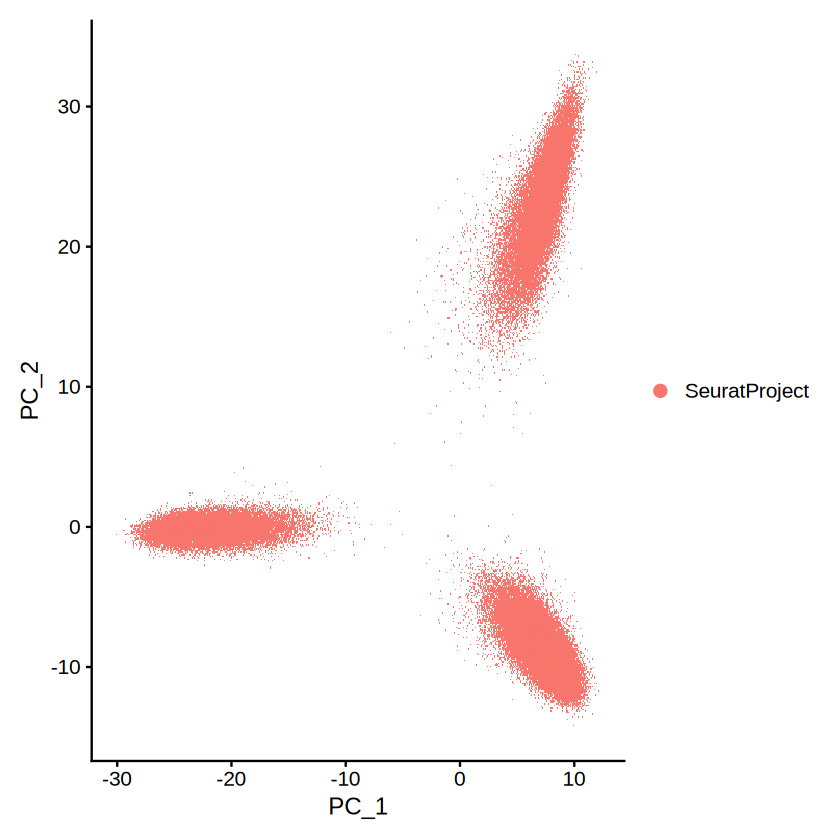

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


In [ ]:
# ============================================================================
# STEP 3: SCALING AND PCA
# ============================================================================

print("Step 3: Scaling Data and PCA")

# Scale the data
all.genes <- rownames(data)
data <- ScaleData(data, features = all.genes)

# Run PCA
data <- RunPCA(data, 
               features = VariableFeatures(object = data),
               npcs = 50)

# Examine and visualize PCA results
print("PCA completed. Top genes for first 5 PCs:")
print(data[["pca"]], dims = 1:20, nfeatures = 5)

# Visualize PCA
DimPlot(data, reduction = "pca")
DimHeatmap(data, dims = 1, cells = 500, balanced = TRUE)

# Determine dimensionality
data <- JackStraw(data, num.replicate = 100)
data <- ScoreJackStraw(data, dims = 1:20)
JackStrawPlot(data, dims = 1:15)

# Alternative: Elbow plot
ElbowPlot(data)

In [ ]:
# ============================================================================
# STEP 4: HARMONY INTEGRATION (IF MULTIPLE SAMPLES)
# ============================================================================
print("Step 4: Harmony Integration Analysis")

# Check if we have multiple samples to integrate
n_samples <- length(unique(data$Sample))
print(paste("Number of unique samples:", n_samples))

if(n_samples > 1) {
  print("Performing Harmony integration across samples...")
  
  # Load harmony library
  library(harmony)
  
  # Run Harmony integration
  data <- RunHarmony(data, group.by.vars = "Sample", verbose = TRUE)
  
  print("Harmony integration completed")
  
} else {
  print("Single sample detected - skipping integration")
}

In [ ]:
# ============================================================================
# STEP 5: CLUSTERING AND UMAP
# ============================================================================

print("Step 5: Clustering and UMAP")

# Find neighbors and cluste
data <- FindNeighbors(data, dims = 1:20)
data <- FindClusters(data, resolution = 0.5)

# Run UMAP
data <- RunUMAP(data, dims = 1:20)

# Visualize
p1 <- DimPlot(data, reduction = "umap", group.by = "cluster")
p2 <- DimPlot(data, reduction = "umap", group.by = "hippocampus_SnC")
p3 <- DimPlot(data, reduction = "umap", group.by = "Sample")

print("UMAP and clustering completed")

# Check cluster assignments vs cell types
print("Cluster vs Cell type distribution:")
print(table(Idents(data), data$cluster))

In [ ]:
p1

In [ ]:
p2

In [ ]:
p3

In [ ]:
library(qs)

In [ ]:
qsave(data, "deseq2_psych_mixed_brain.qs")